In [ ]:
!git clone https://github.com/kpflow369/EDA-IPL

Cloning into 'EDA-IPL'...
remote: Enumerating objects: 148, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 148 (delta 33), reused 23 (delta 18), pack-reused 104 (from 2)
Receiving objects: 100% (148/148), 2.85 MiB | 9.03 MiB/s, done.
Resolving deltas: 100% (59/59), done.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

deliveries_df = pd.read_csv('/content/EDA-IPL/data/deliveries.csv')

print(deliveries_df.columns)

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')


In [ ]:
team_mapping = {
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "RPS": "Rising Pune Supergiants"
}

deliveries_df["bowling_team"] = deliveries_df["bowling_team"].replace(team_mapping)
deliveries_df["batting_team"] = deliveries_df["batting_team"].replace(team_mapping)

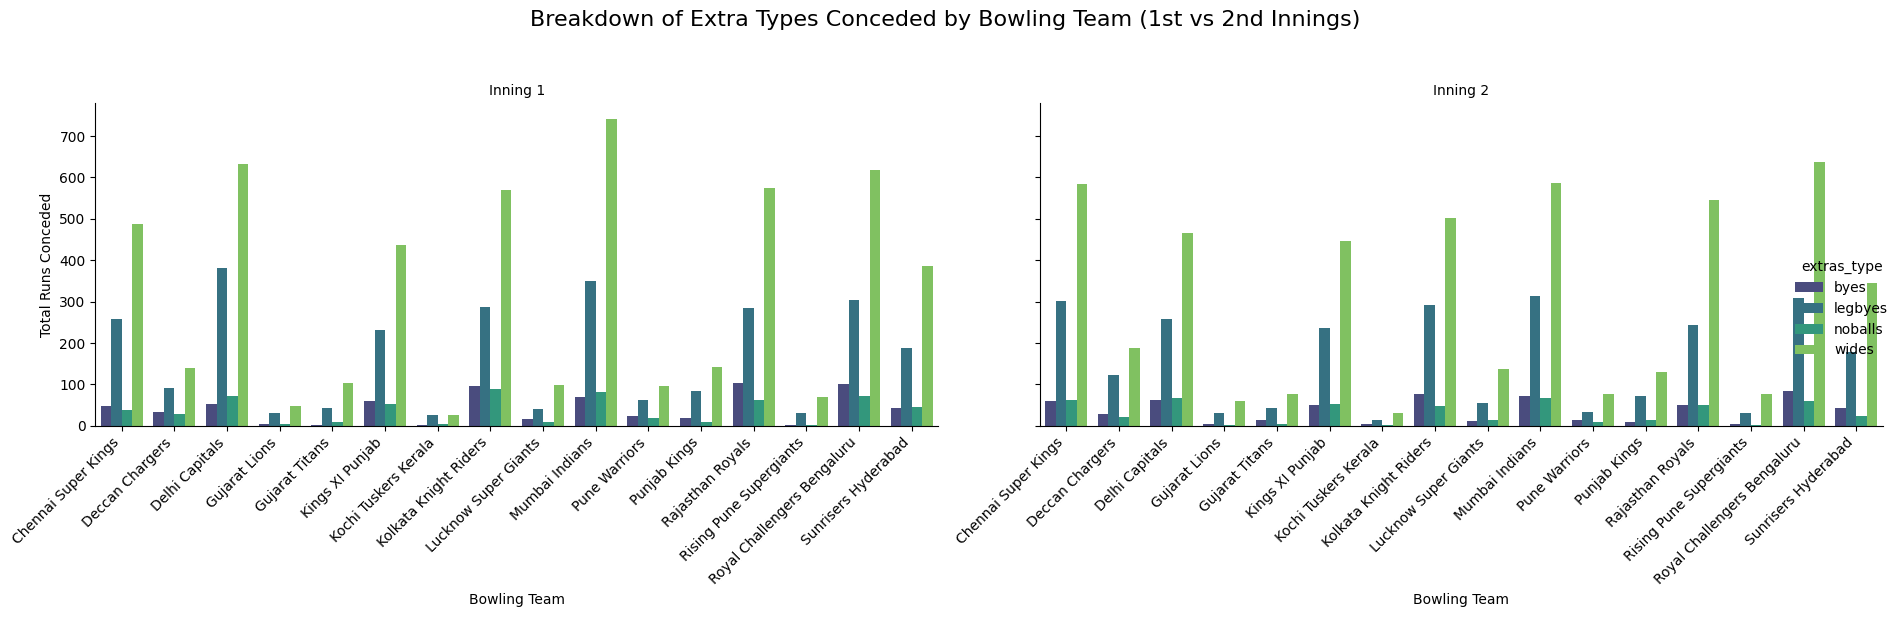

In [8]:
extras_for_viz = deliveries_df_filtered[deliveries_df_filtered['extra_runs'] > 0].copy()

viz_data_grouped = extras_for_viz.groupby(['bowling_team', 'inning', 'extras_type'])['extra_runs'].sum().reset_index()

viz_data_grouped = viz_data_grouped.rename(columns={'extra_runs': 'total_runs'})

viz_data_melted_filtered = viz_data_grouped[viz_data_grouped['extras_type'].isin(['wides', 'noballs', 'legbyes', 'byes'])]

g = sns.catplot(data=viz_data_melted_filtered, x='bowling_team',y='total_runs',hue='extras_type',col='inning',kind='bar',palette='viridis',errorbar=None,height=6, aspect=1.5)

g.set_axis_labels('Bowling Team', 'Total Runs Conceded')
g.set_titles('Inning {col_name}')
g.set_xticklabels(rotation=45, ha='right')
plt.suptitle('Breakdown of Extra Types Conceded by Bowling Team (1st vs 2nd Innings)', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

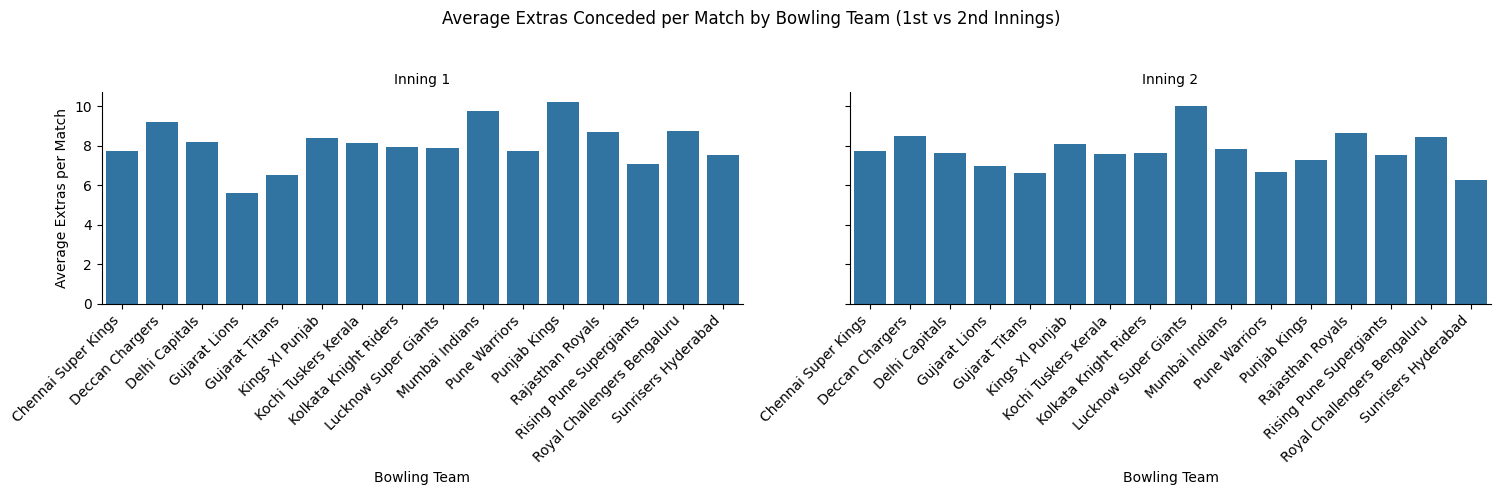

In [ ]:
g = sns.catplot(
    data=avg_extras,
    x='bowling_team',
    y='avg_extras_per_match',
    col='inning',
    kind='bar',
    height=5,
    aspect=1.5
)

g.set_axis_labels('Bowling Team', 'Average Extras per Match')
g.set_titles('Inning {col_name}')
g.set_xticklabels(rotation=45, ha='right')

plt.suptitle('Average Extras Conceded per Match by Bowling Team (1st vs 2nd Innings)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()